<a href="https://colab.research.google.com/github/gsnishanth/demo/blob/main/realdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torchgeo rasterio pyproj -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.4/811.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.2/891.2 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
!pip install "torchgeo[datasets]" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.7 MB/s eta 0:00:00


In [6]:
# Download and install azcopy
!wget -q https://aka.ms/downloadazcopy-v10-linux -O azcopy.tar.gz
!tar -xf azcopy.tar.gz
!sudo cp ./azcopy_linux_amd64_*/azcopy /usr/local/bin/
!sudo chmod +x /usr/local/bin/azcopy

# Verify it's installed and on PATH
!azcopy --version

azcopy version 10.32.7


In [7]:
from torchgeo.datasets import NASAMarineDebris

dataset = NASAMarineDebris(root="data", download=True)
print(f"Number of patches: {len(dataset)}")

Number of patches: 739


In [9]:
sample = dataset[0]
print(sample.keys())
print(sample["image"].shape)
print(sample["bbox_xyxy"])

dict_keys(['image', 'bbox_xyxy'])
torch.Size([3, 256, 256])
tensor([[163,  74, 244, 118],
        [230,   0, 255,  61]])


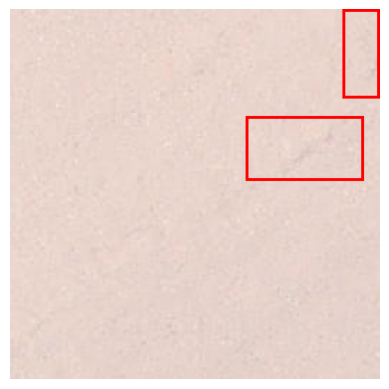

In [11]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

sample = dataset[0]
img = sample["image"]
boxes = sample["bbox_xyxy"]

img_with_boxes = draw_bounding_boxes((img * 255).to(torch.uint8), boxes, colors="red", width=2)
plt.imshow(img_with_boxes.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [12]:
print(img.dtype, img.min(), img.max())

torch.float32 tensor(6.) tensor(71.)


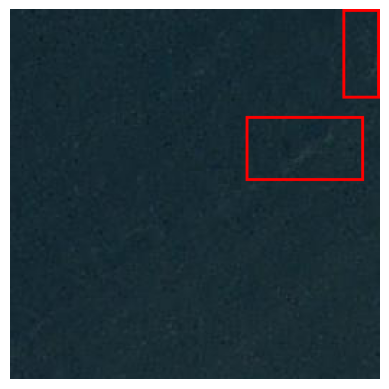

In [13]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes

sample = dataset[0]
img = sample["image"]
boxes = sample["bbox_xyxy"]

img_uint8 = img.clamp(0, 255).to(torch.uint8)
img_with_boxes = draw_bounding_boxes(img_uint8, boxes, colors="red", width=2)

plt.imshow(img_with_boxes.permute(1, 2, 0))
plt.axis("off")
plt.show()

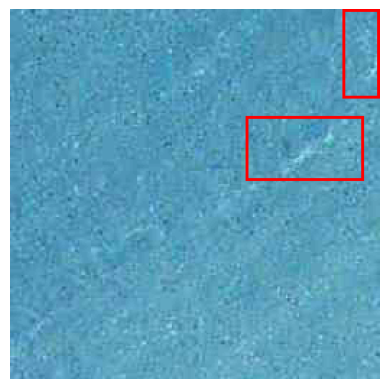

In [14]:
img_stretched = (img / img.max() * 255).clamp(0, 255).to(torch.uint8)
img_with_boxes = draw_bounding_boxes(img_stretched, boxes, colors="red", width=2)
plt.imshow(img_with_boxes.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [15]:
import os
for root, dirs, files in os.walk("data"):
    tifs = [f for f in files if f.endswith(".tif")]
    if tifs:
        print(root, "→", len(tifs), "tif files, e.g.", tifs[0])

data/source → 739 tif files, e.g. 20171015_153720_100c_16969-29816-16.tif


In [16]:
import glob
import rasterio
from pyproj import Transformer
import pandas as pd

# Find all .tif files anywhere under data/
tif_paths = glob.glob("data/**/*.tif", recursive=True)
print(f"Found {len(tif_paths)} tif files")
print(tif_paths[:3])  # sanity check a few paths

rows = []
for path in tif_paths:
    try:
        with rasterio.open(path) as src:
            bounds = src.bounds
            crs = src.crs
            if crs is None:
                continue  # skip if no georeferencing info
            transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
            center_x = (bounds.left + bounds.right) / 2
            center_y = (bounds.bottom + bounds.top) / 2
            lon, lat = transformer.transform(center_x, center_y)
            rows.append({"filename": path, "latitude": lat, "longitude": lon})
    except Exception as e:
        print(f"Skipped {path}: {e}")

df = pd.DataFrame(rows)
print(f"\nExtracted coordinates for {len(df)} images")
df.head()

Found 739 tif files
['data/source/20171015_153720_100c_16969-29816-16.tif', 'data/source/20180224_153958_0f1b_17101-29717-16.tif', 'data/source/20180919_155029_1044_16961-29751-16.tif']

Extracted coordinates for 739 images


,filename,latitude,longitude
0,data/source/20171015_153720_100c_16969-29816-1...,16.000936,-86.783752
1,data/source/20180224_153958_0f1b_17101-29717-1...,16.522999,-86.058655
2,data/source/20180919_155029_1044_16961-29751-1...,16.343861,-86.827698
3,data/source/20170927_154611_0e14_16743-29852-1...,15.810753,-88.025208
4,data/source/20180224_153958_0f1b_17100-29713-1...,16.544063,-86.064148


In [17]:
df.to_csv("data/marine_debris_coordinates.csv", index=False)

In [18]:
!pip install folium -q
import folium

m = folium.Map(location=[df["latitude"].mean(), df["longitude"].mean()], zoom_start=6)
for _, row in df.iterrows():
    folium.CircleMarker([row["latitude"], row["longitude"]], radius=3, color="red", fill=True).add_to(m)
m

In [19]:
counts = []
for i in range(len(dataset)):
    sample = dataset[i]
    counts.append(len(sample["bbox_xyxy"]))

df["debris_count"] = counts
df.sort_values("debris_count", ascending=False).head(10)

,filename,latitude,longitude,debris_count
675,data/source/20181031_095925_103b_32728-31765-1...,5.498438,-0.216980,8
86,data/source/20170326_153234_0e26_17068-29759-1...,16.301687,-86.239929,8
128,data/source/20170326_153233_0e26_17064-29742-1...,16.391296,-86.261902,8
433,data/source/20161008_153105_0e3a_16928-29808-1...,16.043174,-87.008972,7
206,data/source/20170326_153239_0e26_17026-29817-1...,15.995655,-86.470642,7
204,data/source/20170326_153234_0e26_17061-29755-1...,16.322775,-86.278381,7
143,data/source/20181124_155714_1049_16764-29709-1...,16.565125,-87.909851,7
294,data/source/20161008_153105_0e3a_16934-29811-1...,16.027336,-86.976013,6
508,data/source/20170326_153234_0e26_17056-29746-1...,16.370215,-86.305847,6
507,data/source/20161008_153104_0e3a_16807-29816-1...,16.000936,-87.673645,6
